Note : dataset has 70000 images... we will onl use 6000 for faster testing

784->128(reLU)-64(reLU)->10(softmax)


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [22]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the specific CSV file
file_path = "fashion-mnist_train.csv"

# Load the dataset directly into a Pandas DataFrame
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  file_path
)

print("First 5 records:", df.head())


100%|██████████| 33.6M/33.6M [00:03<00:00, 11.0MB/s]

Extracting zip of fashion-mnist_train.csv...


First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0  

In [26]:
torch.device('cuda')

device(type='cuda')

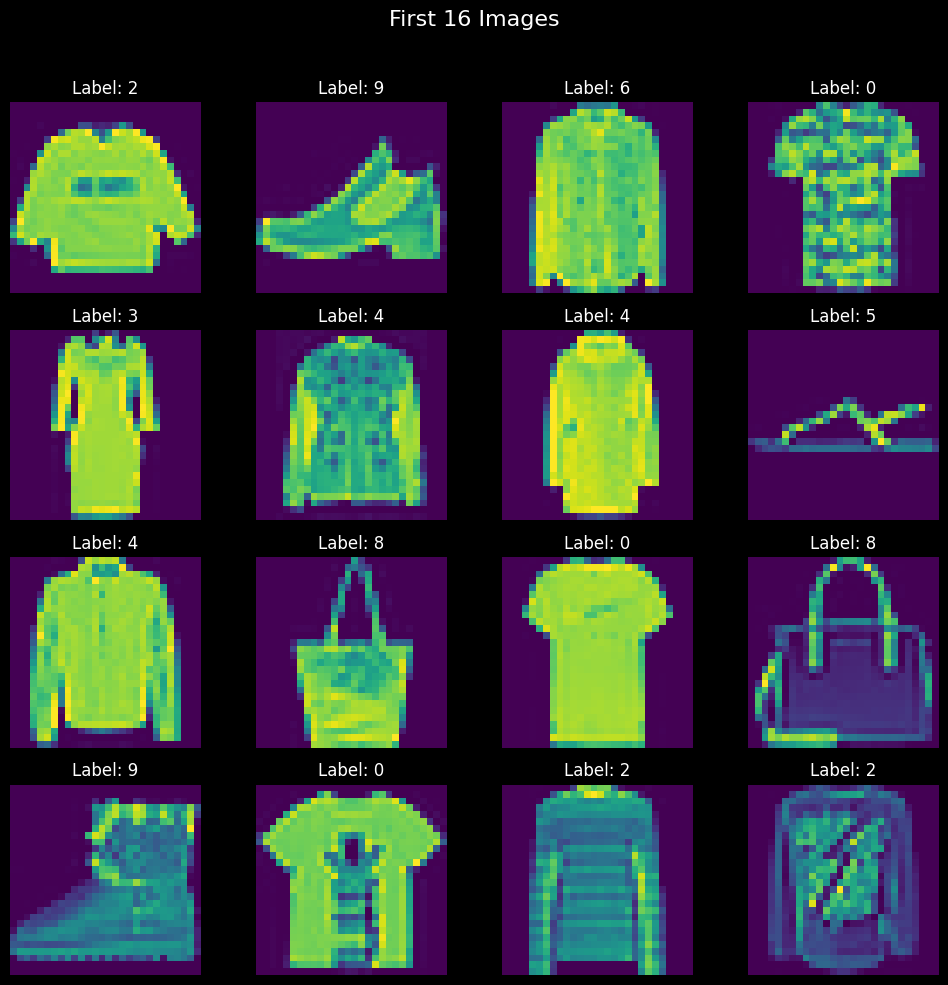

In [27]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [28]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [31]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]



In [32]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [33]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
         0.5333, 0.0000, 0.0

In [34]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [41]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=2)

In [42]:
# define NN class

class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)

In [43]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.1

In [44]:
# instatiate the model
model = MyNN(X_train.shape[1])
model.to(torch.device('cuda'))
# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)

In [45]:
len(train_loader)

1500

In [46]:
# training loop
device = torch.device('cuda')
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:
    batch_features , batch_labels = batch_features.to(device), batch_labels.to(device)
    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.647778323918581
Epoch: 2 , Loss: 0.4335969342639049
Epoch: 3 , Loss: 0.385548681885004
Epoch: 4 , Loss: 0.3563974006337424
Epoch: 5 , Loss: 0.3359697175870339
Epoch: 6 , Loss: 0.3179773036365708
Epoch: 7 , Loss: 0.3062813919832309
Epoch: 8 , Loss: 0.2921208334217469
Epoch: 9 , Loss: 0.28499743800113597
Epoch: 10 , Loss: 0.2755465717352927
Epoch: 11 , Loss: 0.2653332428485155
Epoch: 12 , Loss: 0.2579275383676092
Epoch: 13 , Loss: 0.24978055339306593
Epoch: 14 , Loss: 0.24270352875689666
Epoch: 15 , Loss: 0.23684448226168753
Epoch: 16 , Loss: 0.2308091788465778
Epoch: 17 , Loss: 0.22569835491850973
Epoch: 18 , Loss: 0.2211759120747447
Epoch: 19 , Loss: 0.21506711378321053
Epoch: 20 , Loss: 0.20932213172564904
Epoch: 21 , Loss: 0.2056687358977894
Epoch: 22 , Loss: 0.20138647700939327
Epoch: 23 , Loss: 0.19792715509980918
Epoch: 24 , Loss: 0.18978049986995757
Epoch: 25 , Loss: 0.18957925734110176
Epoch: 26 , Loss: 0.18747998622835924
Epoch: 27 , Loss: 0.18106309713112811

In [47]:
 # evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    batch_features , batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.88775


In [48]:
 # evaluation code
model.eval()
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:
    batch_features , batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.9811458333333334


Test--88%
Training--98%

### Overfitting
#### Solutions
- Adding more data
- Reducing the complexity of NN architecture
- Regularization
- Dropouts
- Data Augmentation
- Batch Normalization
- Early Stopping

# We will implement this in next notebook